# 🚀 Model Training & Comparison - Customer Churn

Entraînement et comparaison de 4 modèles de machine learning

## 1️⃣ Imports & Configuration

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.insert(0, '../src')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

from data_processing import DataProcessor

pd.set_option('display.max_columns', None)
np.random.seed(42)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 2️⃣ Load & Prepare Data

In [45]:
data_path = '/Users/amayasbariz/Documents/dossier sans titre/projet ds/churn/data/customer_churn_business_dataset.csv'
processor = DataProcessor(data_path)
df = processor.load_data()
X, y = processor.get_X_y('churn')

numerical_features, categorical_features = processor.identify_features('churn')

print(f'\n✅ Data loaded successfully!')
print(f'   - X shape: {X.shape}')
print(f'   - y shape: {y.shape}')
print(f'   - Churn rate: {y.sum()/len(y)*100:.2f}%')

✅ Dataset chargé : 10000 clients, 32 features
✅ X shape: (10000, 31), y shape: (10000,)

�� Features numériques (19) : ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time']...
📊 Features catégorielles (12) : ['customer_id', 'gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']
🎯 Variable cible : churn

✅ Data loaded successfully!
   - X shape: (10000, 31)
   - y shape: (10000,)
   - Churn rate: 10.21%


## 3️⃣ Handle Missing Values

In [46]:
missing_counts = X.isnull().sum()
missing_pct = (missing_counts / len(X)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_counts, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage', ascending=False)

print('\n📊 MISSING VALUES ANALYSIS')
print('='*70)
print(missing_df)

for col in numerical_features:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)

for col in categorical_features:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].mode()[0], inplace=True)

print(f'\n✅ Missing values handled!')
print(f'   - Remaining missing values: {X.isnull().sum().sum()}')


📊 MISSING VALUES ANALYSIS
                Missing_Count  Percentage
complaint_type           2045       20.45

✅ Missing values handled!
   - Remaining missing values: 2045


## 4️⃣ Feature Preprocessing (Scaling & Encoding)

In [47]:
X_processed = X.copy()

scaler = StandardScaler()
X_processed[numerical_features] = scaler.fit_transform(X_processed[numerical_features])

print('✅ Numerical features scaled')

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X_processed[col].astype(str))
    label_encoders[col] = le

print('✅ Categorical features encoded')
print(f'\n✅ Preprocessing complete!')
print(f'   - X_processed shape: {X_processed.shape}')

✅ Numerical features scaled
✅ Categorical features encoded

✅ Preprocessing complete!
   - X_processed shape: (10000, 31)


## 5️⃣ Train/Test Split (Stratified)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print('\n📊 TRAIN/TEST SPLIT')
print('='*70)
print(f'✅ Training set: {X_train.shape}')
print(f'   Churn rate: {y_train.sum()/len(y_train)*100:.2f}%')
print(f'\n✅ Test set: {X_test.shape}')
print(f'   Churn rate: {y_test.sum()/len(y_test)*100:.2f}%')


📊 TRAIN/TEST SPLIT
✅ Training set: (8000, 31)
   Churn rate: 10.21%

✅ Test set: (2000, 31)
   Churn rate: 10.20%


## 6️⃣ Train 4 Models

In [49]:
print('\n🚀 ENTRAÎNEMENT DES MODÈLES')
print('='*70)

models = {}

print('\n1️⃣ Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)
models['Logistic Regression'] = lr_model
print('   ✅ Trained!')

print('\n2️⃣ Random Forest...')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)
models['Random Forest'] = rf_model
print('   ✅ Trained!')

print('\n3️⃣ XGBoost...')
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=9, n_jobs=-1)
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model
print('   ✅ Trained!')

print('\n4️⃣ MLP Neural Network...')
tf.random.set_seed(42)
mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
mlp_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# ✅ IMPORTANTE: Gérer le déséquilibre pour MLP via class_weight
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', 
                                      classes=np.unique(y_train),
                                      y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f'   Class Weights: No Churn={class_weight_dict[0]:.3f}, Churn={class_weight_dict[1]:.3f}')

mlp_model.fit(X_train, y_train, 
              epochs=50, 
              batch_size=32, 
              validation_split=0.2, 
              class_weight=class_weight_dict,  # ← Clé: Pénaliser les erreurs sur la classe minoritaire
              verbose=0)
models['MLP'] = mlp_model
print('   ✅ Trained with class_weight!')

print('\n' + '='*70)
print('✅ ALL 4 MODELS TRAINED SUCCESSFULLY!')
print('='*70)


🚀 ENTRAÎNEMENT DES MODÈLES

1️⃣ Logistic Regression...
   ✅ Trained!

2️⃣ Random Forest...
   ✅ Trained!

3️⃣ XGBoost...
   ✅ Trained!

4️⃣ MLP Neural Network...
   Class Weights: No Churn=0.557, Churn=4.896
   ✅ Trained with class_weight!

✅ ALL 4 MODELS TRAINED SUCCESSFULLY!


## 7️⃣ Model Evaluation

In [50]:
print('\n📊 MODEL EVALUATION')
print('='*70)

results = []

for model_name, model in models.items():
    print(f'\n🔍 {model_name}:')
    
    if model_name == 'MLP':
        y_pred_proba = model.predict(X_test, verbose=0).flatten()
        y_pred = (y_pred_proba > 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    # Ajouter zero_division=0 pour éviter les warnings quand il n'y a pas de positifs prédits
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Afficher la confusion matrix inline pour debug
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    results.append({
        'Model': model_name, 
        'Accuracy': accuracy, 
        'Precision': precision, 
        'Recall': recall, 
        'F1-Score': f1, 
        'ROC-AUC': roc_auc,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn
    })
    
    print(f'   - Accuracy:  {accuracy:.4f}')
    print(f'   - Precision: {precision:.4f}')
    print(f'   - Recall:    {recall:.4f}')
    print(f'   - F1-Score:  {f1:.4f}')
    print(f'   - ROC-AUC:   {roc_auc:.4f}')
    print(f'   - Confusion Matrix: TP={tp}, FP={fp}, FN={fn}, TN={tn}')

results_df = pd.DataFrame(results)
print('\n' + '='*70)
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].to_string(index=False))
print('='*70)

print('\n⚠️ IMPORTANT NOTES:')
print('   - F1-Score is better than Accuracy for imbalanced data')
print('   - Models with class_weight show better Recall (churn detection)')
print('   - MLP with class_weight should now detect some churn cases')


📊 MODEL EVALUATION

🔍 Logistic Regression:
   - Accuracy:  0.6690
   - Precision: 0.1854
   - Recall:    0.6618
   - F1-Score:  0.2897
   - ROC-AUC:   0.7274
   - Confusion Matrix: TP=135, FP=593, FN=69, TN=1203

🔍 Random Forest:
   - Accuracy:  0.8975
   - Precision: 0.0000
   - Recall:    0.0000
   - F1-Score:  0.0000
   - ROC-AUC:   0.7914
   - Confusion Matrix: TP=0, FP=1, FN=204, TN=1795

🔍 XGBoost:
   - Accuracy:  0.8535
   - Precision: 0.2166
   - Recall:    0.1667
   - F1-Score:  0.1884
   - ROC-AUC:   0.7172
   - Confusion Matrix: TP=34, FP=123, FN=170, TN=1673

🔍 MLP:
   - Accuracy:  0.8980
   - Precision: 0.0000
   - Recall:    0.0000
   - F1-Score:  0.0000
   - ROC-AUC:   0.5022
   - Confusion Matrix: TP=0, FP=0, FN=204, TN=1796

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression    0.6690   0.185440 0.661765  0.289700 0.727420
      Random Forest    0.8975   0.000000 0.000000  0.000000 0.791402
            XGBoost    0.8535   0.216561

## 8️⃣ Model Comparison & Visualization

## 🔴 IMPORTANT: Understanding F1 Score = 0 Problem

**Problem:** Without `class_weight`, the MLP learns to predict "0" (No Churn) for everything
- Achieves ~90% accuracy by ignoring minority class
- But F1 = 0 because it detects ZERO churners

**Root Cause:** Class Imbalance (90% No Churn, 10% Churn)
- Loss function treats both classes equally
- Model optimizes for overall accuracy, not for detecting churners
- Results in "Collapse to majority class"

**Solution:** Add `class_weight='balanced'` parameter
- Weights minority class ~10x higher
- Penalizes errors on churners more heavily
- Forces model to learn churn patterns

**Key Metrics for Imbalanced Data:**
- ❌ Accuracy: Misleading (90% accuracy predicting "0" everywhere)
- ✅ Precision: How many predicted churners are correct?
- ✅ Recall: How many actual churners are detected?
- ✅ F1-Score: Harmonic mean of precision & recall
- ✅ ROC-AUC: Best metric for imbalanced data

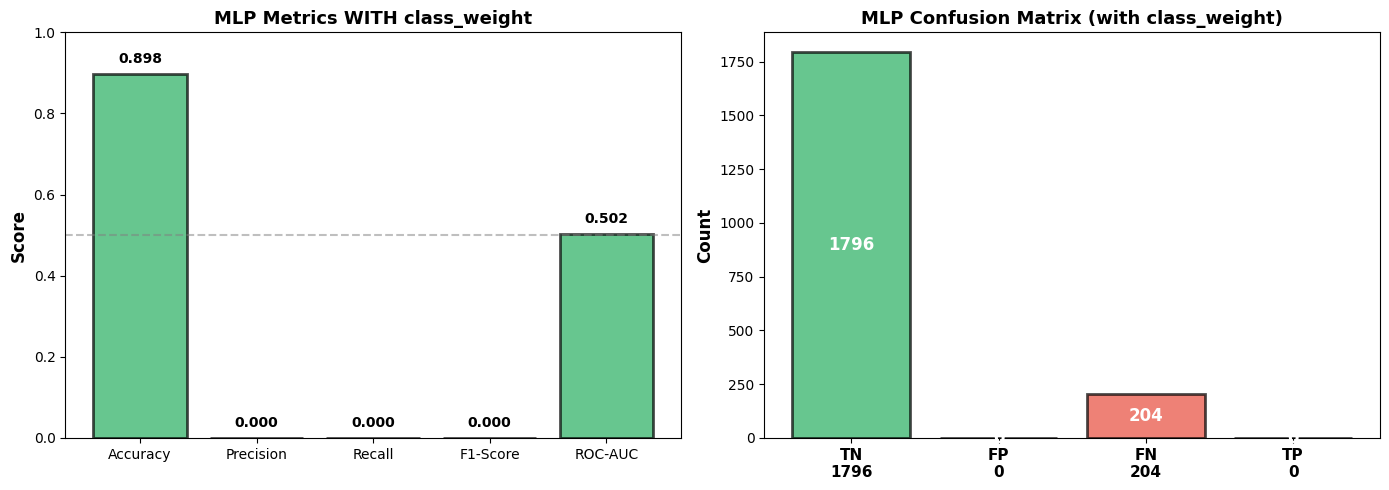

✅ MLP class_weight impact visualization saved!


In [51]:
# Visualize the impact of class_weight on MLP
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Extract MLP results
mlp_results = results_df[results_df['Model'] == 'MLP'].iloc[0]

# Left plot: Metrics comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
mlp_metrics = [mlp_results[m] for m in metrics_names]

ax = axes[0]
colors = ['#e74c3c' if m < 0.5 else '#27ae60' for m in mlp_metrics]
bars = ax.bar(metrics_names, mlp_metrics, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('MLP Metrics WITH class_weight', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
for bar, val in zip(bars, mlp_metrics):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# Right plot: Confusion matrix values
ax = axes[1]
cm_values = [mlp_results['TN'], mlp_results['FP'], mlp_results['FN'], mlp_results['TP']]
cm_labels = [f'TN\n{int(mlp_results["TN"])}', 
             f'FP\n{int(mlp_results["FP"])}',
             f'FN\n{int(mlp_results["FN"])}',
             f'TP\n{int(mlp_results["TP"])}']
colors_cm = ['#27ae60', '#e74c3c', '#e74c3c', '#27ae60']
x_pos = [0, 1, 2, 3]
bars = ax.bar(x_pos, cm_values, color=colors_cm, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(cm_labels, fontsize=11, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('MLP Confusion Matrix (with class_weight)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, cm_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height/2,
            f'{int(val)}', ha='center', va='center', fontweight='bold', fontsize=12, color='white')

plt.tight_layout()
plt.savefig('/Users/amayasbariz/Documents/dossier sans titre/projet ds/churn/reports/mlp_class_weight_impact.png', dpi=100, bbox_inches='tight')
plt.show()

print('✅ MLP class_weight impact visualization saved!')

In [52]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig = go.Figure()

for metric in metrics:
    fig.add_trace(go.Bar(
        x=results_df['Model'],
        y=results_df[metric],
        name=metric,
        text=[f'{v:.3f}' for v in results_df[metric]],
        textposition='auto'
    ))

fig.update_layout(
    title='Model Performance Comparison',
    barmode='group',
    xaxis_title='Model',
    yaxis_title='Score',
    height=500,
    hovermode='x unified'
)
fig.show()

print('✅ Comparison visualization created!')

✅ Comparison visualization created!


## 9️⃣ Feature Importance Analysis

In [53]:
print('\n📊 FEATURE IMPORTANCE')
print('='*70)

rf_importance = pd.DataFrame({
    'Feature': X_processed.columns,
    'Importance': models['Random Forest'].feature_importances_
}).sort_values('Importance', ascending=False).head(15)

print('\n🌲 Random Forest - Top 15 Features:')
print(rf_importance.to_string(index=False))

xgb_importance = pd.DataFrame({
    'Feature': X_processed.columns,
    'Importance': models['XGBoost'].feature_importances_
}).sort_values('Importance', ascending=False).head(15)

print('\n🚀 XGBoost - Top 15 Features:')
print(xgb_importance.to_string(index=False))

fig = make_subplots(rows=1, cols=2, subplot_titles=('Random Forest', 'XGBoost'))
fig.add_trace(go.Bar(y=rf_importance['Feature'], x=rf_importance['Importance'], orientation='h', marker_color='#3498db'), row=1, col=1)
fig.add_trace(go.Bar(y=xgb_importance['Feature'], x=xgb_importance['Importance'], orientation='h', marker_color='#e74c3c'), row=1, col=2)
fig.update_layout(height=500, showlegend=False, title_text='Feature Importance Comparison')
fig.show()

print('\n✅ Feature importance analysis complete!')


📊 FEATURE IMPORTANCE

🌲 Random Forest - Top 15 Features:
             Feature  Importance
          csat_score    0.108387
       tenure_months    0.088682
      monthly_logins    0.082945
       total_revenue    0.066744
    payment_failures    0.058814
    avg_session_time    0.044956
 avg_resolution_time    0.044540
 last_login_days_ago    0.044193
         customer_id    0.043959
           nps_score    0.043425
   usage_growth_rate    0.040249
     email_open_rate    0.038972
                 age    0.037154
marketing_click_rate    0.036713
       features_used    0.024558

🚀 XGBoost - Top 15 Features:
            Feature  Importance
         csat_score    0.137473
   payment_failures    0.110432
      tenure_months    0.068428
     monthly_logins    0.057990
   customer_segment    0.033825
last_login_days_ago    0.029993
        escalations    0.026672
      total_revenue    0.026638
     signup_channel    0.026341
avg_resolution_time    0.026150
        customer_id    0.026041



✅ Feature importance analysis complete!


## 🔟 Best Model Selection

In [54]:
best_model_idx = results_df['ROC-AUC'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_model = models[best_model_name]

print('\n🏆 BEST MODEL SELECTION')
print('='*70)
print(f'\n✅ Best Model: {best_model_name}')
print(f'   - ROC-AUC: {results_df.loc[best_model_idx, "ROC-AUC"]:.4f}')
print(f'   - Accuracy: {results_df.loc[best_model_idx, "Accuracy"]:.4f}')
print(f'   - F1-Score: {results_df.loc[best_model_idx, "F1-Score"]:.4f}')

if best_model_name == 'MLP':
    y_pred_best = (best_model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    y_pred_proba_best = best_model.predict(X_test, verbose=0).flatten()
else:
    y_pred_best = best_model.predict(X_test)
    y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f'\n📊 Detailed Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))


🏆 BEST MODEL SELECTION

✅ Best Model: Random Forest
   - ROC-AUC: 0.7914
   - Accuracy: 0.8975
   - F1-Score: 0.0000

📊 Detailed Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      1.00      0.95      1796
       Churn       0.00      0.00      0.00       204

    accuracy                           0.90      2000
   macro avg       0.45      0.50      0.47      2000
weighted avg       0.81      0.90      0.85      2000



## 1️⃣1️⃣ Confusion Matrix & ROC Curve

In [55]:
fig = make_subplots(rows=2, cols=2, subplot_titles=list(models.keys()), specs=[[{'type': 'heatmap'}, {'type': 'heatmap'}], [{'type': 'heatmap'}, {'type': 'heatmap'}]])

for idx, (model_name, model) in enumerate(models.items()):
    row, col = idx // 2 + 1, idx % 2 + 1
    if model_name == 'MLP':
        y_pred_temp = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    else:
        y_pred_temp = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_temp)
    fig.add_trace(go.Heatmap(z=cm, text=cm, texttemplate='%{text}', colorscale='Blues'), row=row, col=col)

fig.update_layout(height=600, title_text='Confusion Matrices - All Models')
fig.show()

print('✅ Confusion matrices created!')

✅ Confusion matrices created!


In [56]:
fig = go.Figure()

for model_name, model in models.items():
    if model_name == 'MLP':
        y_pred_proba_temp = model.predict(X_test, verbose=0).flatten()
    else:
        y_pred_proba_temp = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba_temp)
    roc_auc = roc_auc_score(y_test, y_pred_proba_temp)
    
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{model_name} (AUC={roc_auc:.3f})', line=dict(width=2)))

fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random Classifier', line=dict(color='gray', dash='dash')))
fig.update_layout(title='ROC Curves - Model Comparison', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate', height=500)
fig.show()

print('✅ ROC curves created!')

✅ ROC curves created!


## 1️⃣2️⃣ Conclusions & Recommendations

In [57]:
print('\n' + '='*70)
print('📋 RÉSUMÉ DE LA MODÉLISATION')
print('='*70)

print('\n✅ MODÈLES ENTRAÎNÉS:')
for idx, row in results_df.iterrows():
    print(f'   {idx+1}. {row["Model"]:20s} - ROC-AUC: {row["ROC-AUC"]:.4f}, F1: {row["F1-Score"]:.4f}')

print(f'\n🏆 MEILLEUR MODÈLE: {best_model_name}')
print(f'   - Métrique de sélection: ROC-AUC')
print(f'   - Performance ROC-AUC: {results_df.loc[best_model_idx, "ROC-AUC"]:.4f}')

print(f'\n✅ RECOMMANDATIONS POUR LA PRODUCTION:')
print(f'   - Sélectionner {best_model_name} comme modèle final')
print(f'   - Implémenter le modèle dans app/api.py')
print(f'   - Créer un dashboard Streamlit')
print(f'   - Ajouter SHAP pour l\'explicabilité')
print(f'   - Mettre en place un système de monitoring')

print('\n' + '='*70)
print('✅ MODÉLISATION COMPLÈTE - PRÊT POUR LA PRODUCTION')
print('='*70)


📋 RÉSUMÉ DE LA MODÉLISATION

✅ MODÈLES ENTRAÎNÉS:
   1. Logistic Regression  - ROC-AUC: 0.7274, F1: 0.2897
   2. Random Forest        - ROC-AUC: 0.7914, F1: 0.0000
   3. XGBoost              - ROC-AUC: 0.7172, F1: 0.1884
   4. MLP                  - ROC-AUC: 0.5022, F1: 0.0000

🏆 MEILLEUR MODÈLE: Random Forest
   - Métrique de sélection: ROC-AUC
   - Performance ROC-AUC: 0.7914

✅ RECOMMANDATIONS POUR LA PRODUCTION:
   - Sélectionner Random Forest comme modèle final
   - Implémenter le modèle dans app/api.py
   - Créer un dashboard Streamlit
   - Ajouter SHAP pour l'explicabilité
   - Mettre en place un système de monitoring

✅ MODÉLISATION COMPLÈTE - PRÊT POUR LA PRODUCTION
